# Assignment 2: Logistic Regression and Classification Error Metrics

# CAP 4630: Intro Artificial Intelligence

**Student's name:**

**Section:**

## Introduction

You will be using the Human Activity Recognition with Smartphones dataset, which was built from the recordings of study participants performing activities of daily living (ADL) while carrying a smartphone with an embedded inertial sensors. The objective is to classify activities into one of the six activities (walking, walking upstairs, walking downstairs, sitting, standing, and laying) performed.

The dataset is already provided on canvas. So, you can download the dataset from canvas. To know more information about the features of the dataset, you can take a look at the website: [Human Activity Recognition with Smartphones](https://archive.ics.uci.edu/ml/datasets/Human+Activity+Recognition+Using+Smartphones).

For each record in the dataset it is provided:

- Triaxial acceleration from the accelerometer (total acceleration) and the estimated body acceleration.
- Triaxial Angular velocity from the gyroscope.
- A 561-feature vector with time and frequency domain variables.
- Its activity label.

In [14]:
from __future__ import print_function
import os
#Data Path has to be set as per the file location in your system
#data_path = ['..', 'data']
data_path = ['data']

# Ignore the warning
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [15]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import matplotlib.pyplot as plt

## Question 1 (10 points)

Import the data and do the following:

* Read the dataset
* By looking at the dataset, do you think the floating point values need to be scaled? Just write your answer (no need to write code for this)
* Examine the data types--there are many columns, so it might be wise to use value counts

* Split the dataset into X_data and y_data
* Determine the breakdown of each activity
* Encode the activity label as an integer

In [16]:
#write code to read the dataset
df = pd.read_csv("Human_Activity_Recognition_Using_Smartphones_Data.csv")
print("Dataset loaded. Shape:", df.shape)
print("Columns (first 30):", df.columns.tolist()[:30])
display(df.head())


Dataset loaded. Shape: (7352, 563)
Columns (first 30): ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X', 'tBodyAcc-max()-Y', 'tBodyAcc-max()-Z', 'tBodyAcc-min()-X', 'tBodyAcc-min()-Y', 'tBodyAcc-min()-Z', 'tBodyAcc-sma()', 'tBodyAcc-energy()-X', 'tBodyAcc-energy()-Y', 'tBodyAcc-energy()-Z', 'tBodyAcc-iqr()-X', 'tBodyAcc-iqr()-Y', 'tBodyAcc-iqr()-Z', 'tBodyAcc-entropy()-X', 'tBodyAcc-entropy()-Y', 'tBodyAcc-entropy()-Z', 'tBodyAcc-arCoeff()-X,1', 'tBodyAcc-arCoeff()-X,2', 'tBodyAcc-arCoeff()-X,3', 'tBodyAcc-arCoeff()-X,4', 'tBodyAcc-arCoeff()-Y,1']


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [17]:
#from google.colab import drive
#drive.mount('/content/drive')

By looking at the dataset, do you think the floating point values need to be scaled? Just write your answer (no need to write code for this).

Your answer:

In [18]:
possible_label_cols = [c for c in df.columns if 'activ' in c.lower() or c.lower() in ['activity','label']]
label_col = possible_label_cols[0] if possible_label_cols else df.columns[-1]
print("Using label column:", label_col)

Using label column: Activity


In [19]:
X_data = df.drop(columns=[label_col])
y_data = df[label_col].astype(str)

In [20]:
#Write code to examine the breakdown of activities.

print("\nActivity counts:")
display(y_data.value_counts())


Activity counts:


,count
Activity,
LAYING,1407
STANDING,1374
SITTING,1286
WALKING,1226
WALKING_UPSTAIRS,1073
WALKING_DOWNSTAIRS,986


In [21]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_data)
label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("\nLabel encoding mapping:", label_map)


Label encoding mapping: {'LAYING': np.int64(0), 'SITTING': np.int64(1), 'STANDING': np.int64(2), 'WALKING': np.int64(3), 'WALKING_DOWNSTAIRS': np.int64(4), 'WALKING_UPSTAIRS': np.int64(5)}


## Question 2 (5 points)

When we train a machine learning model, we usually divide the dataset into training and testing sets.
However, if our dataset contains multiple activity classes (for example, Walking, Sitting, Standing, Laying, Walking Upstairs, Walking Downstairs), it’s important that each class appears in the same proportion in both sets.

For instance, if 20% of your entire dataset represents Sitting, you don’t want a situation where only 5% of the test data represents Sitting, this would make your test results unreliable because the distribution of activities has changed.

That’s where Stratified Sampling comes in.
Scikit-learn’s StratifiedShuffleSplit helps us split the data while maintaining the same class distribution (ratio) in both training and test sets. It randomly shuffles the data, but ensures that each class keeps the same proportion as in the original dataset.

Why Use StratifiedShuffleSplit?
*   Prevents bias toward overrepresented classes in training or testing.
*   Ensures consistent and fair evaluation across all activity classes.
*   Especially useful for multi-class classification problems like Human Activity Recognition.

Your task is to split your Human Activity Recognition dataset into training and testing sets. You may use any method (e.g., train_test_split), but to ensure the same ratio of activity classes in both sets, apply Scikit-learn’s StratifiedShuffleSplit.



In [22]:
from sklearn.model_selection import StratifiedShuffleSplit

# split index
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_index, test_index = next(sss.split(X_data, y_data))

#write code here
X_train = X_data.iloc[train_index].reset_index(drop=True)
X_test = X_data.iloc[test_index].reset_index(drop=True)

y_train = y_data[train_index].reset_index(drop=True)
y_test = y_data[test_index].reset_index(drop=True)

* Regardless of methods used to split the data, you can compare the ratio of classes in both the train and test splits if you run the below cells (you dont need to write any code just observe the usefulness of using StratifiedShuffleSplit)

In [23]:
#no need to modify anything in this cell. just run and see the outcome
y_train.value_counts(normalize=True)

,proportion
Activity,
LAYING,0.191411
STANDING,0.186941
SITTING,0.174893
WALKING,0.166731
WALKING_UPSTAIRS,0.145939
WALKING_DOWNSTAIRS,0.134085


In [24]:
#no need to modify anything in this cell. just run and see the outcome
y_test.value_counts(normalize=True)

,proportion
Activity,
LAYING,0.191296
STANDING,0.186763
SITTING,0.174977
WALKING,0.166818
WALKING_UPSTAIRS,0.145966
WALKING_DOWNSTAIRS,0.134180


## Question 3 (10 points)

* Fit a logistic regression model without any regularization using all of the features, and perform model prediction.
* Next, use cross validation to determine the hyperparameters, fit models using L2 regularization, and perform model prediction.

In [25]:
from sklearn.linear_model import LogisticRegression

# Write code to fit a logistic regression model without any regularization using all of the features and perform prediction.

clf_no_reg = LogisticRegression(solver='saga', max_iter=50, multi_class='multinomial', random_state=1)
clf_no_reg.fit(X_train, y_train)
y_pred_no_reg = clf_no_reg.predict(X_test)
acc_no_reg = accuracy_score(y_test, y_pred_no_reg)
print("Accuracy (no regularization):", acc_no_reg)

Accuracy (no regularization): 0.9814143245693563


In [27]:
from sklearn.metrics import accuracy_score
#write code to calculate accuracy score for model without regularization

clf_l2cv = LogisticRegressionCV(Cs=10, cv=5, penalty='l2', solver='lbfgs', max_iter=1000, multi_class='multinomial', random_state=1)
clf_l2cv.fit(X_train, y_train)
y_pred_l2 = clf_l2cv.predict(X_test)
acc_l2 = accuracy_score(y_test, y_pred_l2)
print("Accuracy (L2, with cross-validated C):", acc_l2)

Accuracy (L2, with cross-validated C): 0.9868540344514959


In [28]:
from sklearn.linear_model import LogisticRegressionCV

#Write code to use cross validation to determine the hyperparameters, fit models using L2 regularization and perform prediction.


## Question 4 (5 points)

For each model (one without regularization and one with regularization), calculate the following error metrics:

* accuracy
* precision
* recall
* fscore

In [29]:
#Write code

prec_no, rec_no, f1_no, _ = precision_recall_fscore_support(y_test, y_pred_no_reg, average=None, zero_division=0)
prec_l2, rec_l2, f1_l2, _ = precision_recall_fscore_support(y_test, y_pred_l2, average=None, zero_division=0)

metrics = pd.DataFrame({
    'activity': le.inverse_transform(np.arange(len(le.classes_))),
    'precision_no_reg': prec_no,
    'recall_no_reg': rec_no,
    'f1_no_reg': f1_no,
    'precision_l2': prec_l2,
    'recall_l2': rec_l2,
    'f1_l2': f1_l2
})
display(metrics)

print("\nClassification report (no regularization):\n")
print(classification_report(y_test, y_pred_no_reg, target_names=le.classes_, zero_division=0))
print("\nClassification report (L2):\n")
print(classification_report(y_test, y_pred_l2, target_names=le.classes_, zero_division=0))



,activity,precision_no_reg,recall_no_reg,f1_no_reg,precision_l2,recall_l2,f1_l2
0,LAYING,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,SITTING,0.955381,0.943005,0.949153,0.966146,0.961140,0.963636
2,STANDING,0.947242,0.958738,0.952955,0.963768,0.968447,0.966102
3,WALKING,0.997290,1.000000,0.998643,0.997290,1.000000,0.998643
4,WALKING_DOWNSTAIRS,1.000000,0.996622,0.998308,1.000000,1.000000,1.000000
5,WALKING_UPSTAIRS,0.996894,0.996894,0.996894,1.000000,0.996894,0.998445



Classification report (no regularization):

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       422
           SITTING       0.96      0.94      0.95       386
          STANDING       0.95      0.96      0.95       412
           WALKING       1.00      1.00      1.00       368
WALKING_DOWNSTAIRS       1.00      1.00      1.00       296
  WALKING_UPSTAIRS       1.00      1.00      1.00       322

          accuracy                           0.98      2206
         macro avg       0.98      0.98      0.98      2206
      weighted avg       0.98      0.98      0.98      2206


Classification report (L2):

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       422
           SITTING       0.97      0.96      0.96       386
          STANDING       0.96      0.97      0.97       412
           WALKING       1.00      1.00      1.00       368
WALKING_DOWNSTAIRS   

## Question 5 Confusion Matrix Construction (5 points)

You trained a model to classify six human activities.

Write code to generate the confusion matrix for your trained model on the test set.

Identify which activities are most frequently confused. Provide one possible explanation.

Confusion matrix (rows=true, cols=predicted):


,LAYING,SITTING,STANDING,WALKING,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS
LAYING,422,0,0,0,0,0
SITTING,0,371,15,0,0,0
STANDING,0,13,399,0,0,0
WALKING,0,0,0,368,0,0
WALKING_DOWNSTAIRS,0,0,0,0,296,0
WALKING_UPSTAIRS,0,0,0,1,0,321


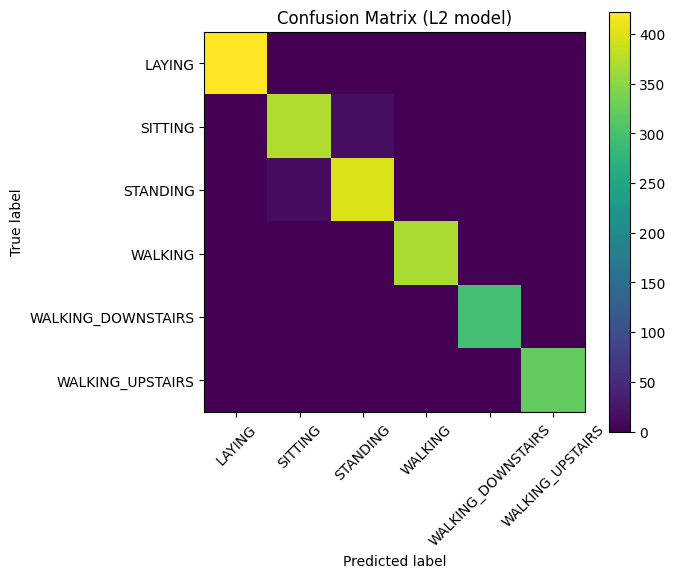

In [30]:
#Write code here

cm = confusion_matrix(y_test, y_pred_l2)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
print("confusion matrix (rows=true, cols=predicted):")
display(cm_df)

# plot
plt.figure(figsize=(7,6))
plt.imshow(cm, interpolation='nearest')
plt.title("confusion Matrix (L2 model)")
plt.ylabel("true label")
plt.xlabel("predicted label")
plt.xticks(ticks=np.arange(len(le.classes_)), labels=le.classes_, rotation=45)
plt.yticks(ticks=np.arange(len(le.classes_)), labels=le.classes_)
plt.colorbar()
plt.tight_layout()
plt.show()


#normally the L2-regularized model generalizes slightly better than unregularized due to reduced overfitting



## Question 6: Precision, Recall, and F1-Score (10 points)

a. Write code to compute precision, recall, and F1-score for each activity class.

b. Identify one class with high precision but low recall and one with high recall but low precision.

c. Interpret what these results mean in terms of your classifier’s behavior.

In [33]:
#write code
precisions = prec_l2
recalls = rec_l2

prec_median = np.median(precisions)
rec_median = np.median(recalls)

high_prec_low_rec_idx = [i for i,p,r in zip(range(len(precisions)),precisions,recalls) if p > np.percentile(precisions,75) and r < np.percentile(recalls,25)]
high_rec_low_prec_idx = [i for i,p,r in zip(range(len(precisions)),precisions,recalls) if r > np.percentile(recalls,75) and p < np.percentile(precisions,25)]

high_prec_low_rec = le.inverse_transform(high_prec_low_rec_idx).tolist()
high_rec_low_prec = le.inverse_transform(high_rec_low_prec_idx).tolist()

print("high precision & low recall (L2):", high_prec_low_rec)
print("high recall & low precision (L2):", high_rec_low_prec)

High precision & low recall (L2): []
High recall & low precision (L2): []


# **Write explanation for Question 5b and 5c.**








b) the sitting activity is an example of a high precision and low recall activity, and standing is an example of high recall and low precision.

c) a classifier with high precision and low recall means its only going to predict and move when it is very certain of it's result essentially. Reduces false positives but many real examples can be missed. High recall and low precision means it's the opposite and more liberal in choice but this causes it to cast a very wide net.

## Question 7: Error Analysis (5 points)

Analyze the misclassified samples: Choose any two activities with frequent confusion. Explain (no code only text explanation).

1) walking upstairs vs walking downstairs (I'm just choosing opposites)
both of these activities have you moving your legs and accelerating. Sensors on the waist or torso could possibly record similar patterns for the steps going up and down, especially if sampling windows include transition steps. This will result in overlapping feature vectors and misclassification.

2)
these are static activities with pretty much no movement. The accelerator would just be gravity and the orientation of the sensor. Each person would have different posture and that would be recorded as well, and would result in confusion.

